## Social Media Analytics Pipeline - Phase 2
### SQL Queries and Boolean search filters

**Phase:** 2 of 4 - SQL Analytics and Boolean Social Filter  
**Input:** social_analytic.db - Created in Phase 1

---
### What this notebook does
| Step | Task | Tool |
|------|------|------|
| 1 | Connect to SQLite database | SQL |
| 2 | Engagement analysis queries |  |
| 3 | Content release timeline queries | |
| 4 | Platform & Franchise performance | |
| 5 | Boolean search filter libraryy ||
|6 | Community engagement analysis | |
|7 | Export results for Power BI ||


### Step 1 - Setup and connect to Database

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import re
import inspect
from datetime import datetime

# ----- CONFIG -------------
DB_FILE = "social_media_analytics.db"
table_name = "social_media_posts"
db_path = os.path.abspath("social_media_analytics.db")

# Connect and verify database
connection = sqlite3.connect(DB_FILE)
row_count = pd.read_sql(f"SELECT COUNT(*) AS total FROM {table_name}",
                       connection).iloc[0,0] 
col_info = pd.read_sql(f"PRAGMA table_info({table_name})",
                      connection)

print(f"Connect to: {DB_FILE}")
print(f" Rows: {row_count:,}")
print(f" Columns: {len(col_info)}")
print(f"\n Available columns: ")
for col in col_info["name"].tolist():
    print(f"   {col}")

Connect to: social_media_analytics.db
 Rows: 5,000
 Columns: 25

 Available columns: 
   post_id
   post_date
   platform
   content_type
   category
   likes
   comments
   shares
   views
   saves
   followers
   engagement_rate
   hour_of_day
   day_of_week
   hashtag_count
   content_length
   sentiment
   influencer
   has_media
   is_verified
   caption
   post_date_str
   post_month
   post_weekday
   franchise_group


In [2]:
# Run SQL and display results
def run_query(sql, title = ""):
    df = pd.read_sql(sql,connection)
    if title: 
        print(f"\n {title}")
        print("-"*50)
    display(df)
    return df


# preview the table
run_query(f"SELECT * FROM {table_name} LIMIT 5", "Sample rows")
print(inspect.getsource(run_query))


 Sample rows
--------------------------------------------------


,post_id,post_date,platform,content_type,category,likes,comments,shares,views,saves,...,content_length,sentiment,influencer,has_media,is_verified,caption,post_date_str,post_month,post_weekday,franchise_group
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,...,985,Positive,Macro,1,0,,2026-01-01,2026-01,Unknown,Tech & Business
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,...,627,Negative,Macro,0,1,,2026-01-01,2026-01,Unknown,Health & Wellness
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,...,79,Positive,Macro,1,1,,2026-01-01,2026-01,Unknown,Health & Wellness
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,...,554,Neutral,Macro,1,0,,2026-01-01,2026-01,Unknown,Sports & Fitness
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,...,1136,Positive,Mid-tier,1,0,,2026-01-01,2026-01,Unknown,Sports & Fitness


def run_query(sql, title = ""):
    df = pd.read_sql(sql,connection)
    if title: 
        print(f"\n {title}")
        print("-"*50)
    display(df)
    return df



### Step 2 - Enagagement Analysis Queries  
Question: Which content drives the most engagement, and when 


In [3]:
# Average engagement rate by platform
q1 = run_query(f"""
    SELECT 
        platform, 
        COUNT(*)  AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        ROUND(MAX(engagement_rate),2) AS max_engagement,
        SUM(likes) AS total_likes,
        SUM(comments) AS total_comments,
        SUM(shares) AS total_shares
    FROM {table_name}
    GROUP BY platform
    ORDER BY avg_engagement DESC
""", "Q1 - Avg Engagement Rate by Platform")

print(type(q1))



 Q1 - Avg Engagement Rate by Platform
--------------------------------------------------


,platform,total_posts,avg_engagement,max_engagement,total_likes,total_comments,total_shares
0,TikTok,758,41.34,3510.0,19556373,773735,1894915
1,YouTube,479,9.95,305.0,4778847,237233,470373
2,Instagram,1283,7.64,1092.0,6342290,309406,193680
3,Facebook,984,6.67,816.0,4081807,194241,486593
4,Twitter,994,4.26,511.0,2405120,147024,1001785
5,LinkedIn,502,1.31,84.0,519755,37855,128821


<class 'pandas.core.frame.DataFrame'>


In [4]:
# Q2 - Top performing content types
q2 = run_query(f"""
    SELECT 
        content_type,
        COUNT(*)                          AS  total_posts,
        ROUND(AVG(engagement_rate),2)     AS avg_engagement,
        ROUND(AVG(likes),0)               AS avg_likes,
        ROUND(AVG(shares),0)              AS avg_shares,
        ROUND(AVG(comments),0)            AS avg_comments
    FROM {table_name}
    GROUP BY content_type
    ORDER BY avg_engagement DESC
""", "Q2 - Performance by Content Type")



 Q2 - Performance by Content Type
--------------------------------------------------


,content_type,total_posts,avg_engagement,avg_likes,avg_shares,avg_comments
0,Stitch,259,44.91,25421.0,2435.0,1014.0
1,Duet,248,41.13,26245.0,2520.0,1058.0
2,Video,616,19.92,13913.0,1392.0,568.0
3,Reel,306,11.19,4918.0,154.0,249.0
4,Short,121,10.22,9412.0,1015.0,447.0
5,Community Post,135,9.64,9908.0,1017.0,484.0
6,Carousel,333,7.90,5039.0,147.0,240.0
7,Post,378,7.24,3222.0,400.0,148.0
8,Live,358,6.91,6182.0,675.0,316.0
9,Photo,320,5.82,4809.0,151.0,243.0


In [5]:
# Q3 - Best posting hour of day 
q3 = run_query(f"""
    SELECT 
        hour_of_day,
        COUNT(*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        ROUND(AVG(likes),0) AS avg_likes
    FROM {table_name}
    WHERE hour_of_day IS NOT NULL
    GROUP BY hour_of_day
    ORDER BY avg_engagement DESC
    LIMIT 10
""","Q3 - Top 10 Best Hours to Post")


 Q3 - Top 10 Best Hours to Post
--------------------------------------------------


,hour_of_day,total_posts,avg_engagement,avg_likes
0,8,208,24.13,6518.0
1,20,231,22.63,8064.0
2,7,200,21.51,7690.0
3,18,176,15.78,8333.0
4,0,196,15.26,7761.0
5,1,207,15.12,8038.0
6,9,216,12.31,6304.0
7,16,200,12.26,8301.0
8,14,197,11.03,7877.0
9,13,225,11.02,7407.0


In [6]:
# Q4 - Best day of week
q4 = run_query(f"""
    SELECT 
        day_of_week,
        COUNT(*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        ROUND(AVG(likes),0) AS avg_likes,
        ROUND(AVG(shares),0) AS avg_shares
    FROM {table_name}
    WHERE day_of_week IS NOT NULL
    GROUP BY day_of_week
    ORDER BY avg_engagement DESC        
""", "Q4 - Engagment by Day of Week")


 Q4 - Engagment by Day of Week
--------------------------------------------------


,day_of_week,total_posts,avg_engagement,avg_likes,avg_shares
0,Friday,711,18.62,7295.0,845.0
1,Monday,719,12.61,7370.0,790.0
2,Saturday,705,11.67,7245.0,817.0
3,Tuesday,717,10.94,7696.0,843.0
4,Thursday,715,9.32,7818.0,858.0
5,Sunday,706,8.94,7024.0,834.0
6,Wednesday,727,8.27,8286.0,859.0


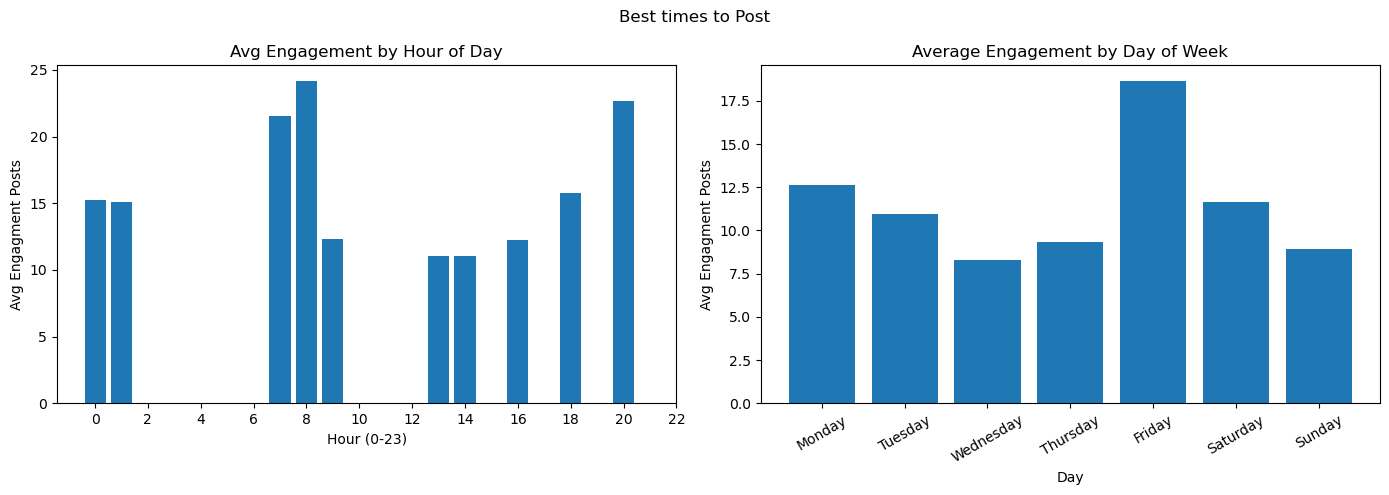

<Figure size 640x480 with 0 Axes>

In [7]:
# Visualize Q3 and Q4 
fig, axes = plt.subplots(1,2, figsize = (14,5))
fig.suptitle("Best times to Post")

# use the aboved table
axes[0].bar(q3["hour_of_day"],q3["avg_engagement"])
axes[0].set_title("Avg Engagement by Hour of Day")
axes[0].set_xlabel("Hour (0-23)")
axes[0].set_ylabel("Avg Engagment Posts")
axes[0].set_xticks(range(0,24,2))

# create new table using SQL query
day_order = ["Monday", "Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
q4_new = pd.read_sql(f"""
        SELECT 
            day_of_week,
            COUNT (*) AS total_posts,
            ROUND(AVG(engagement_rate),2) AS avg_engagement
        FROM {table_name} 
        WHERE day_of_week IS NOT NULL
        GROUP BY day_of_week
""",connection)
q4_sorted = q4_new.set_index("day_of_week").reindex(
    [d for d in day_order if d in q4_new["day_of_week"].values]
)
axes[1].bar(q4_sorted.index, q4_sorted["avg_engagement"])
axes[1].set_title("Average Engagement by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Avg Engagment Posts")
axes[1].tick_params(axis='x',rotation = 30)
 
plt.tight_layout()
plt.show() 
plt.savefig("engagement_timing.png")



### Step 3 - Content Release Timeline Queries  
This queries track **when content was released** and **how it performed across release phases**.



In [8]:
# Q5 - Monthly content volume and engagment trend
q5 = run_query(f"""
    SELECT
        SUBSTR(post_date,1,7) AS month,
        COUNT (*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        SUM(likes) AS total_likes,
        SUM(shares) AS total_shares
    FROM {table_name}
    WHERE post_date IS NOT NULL
    GROUP BY SUBSTR(post_date,1,7)
    ORDER BY month ASC
    LIMIT 10
""", " Q5 - Monthly content volume & Engagement trend")


  Q5 - Monthly content volume & Engagement trend
--------------------------------------------------


,month,total_posts,avg_engagement,total_likes,total_shares
0,2024-01,184,14.79,1373447,129006
1,2024-02,190,12.68,1704248,166527
2,2024-03,218,12.44,1935586,203341
3,2024-04,236,8.63,1828457,196183
4,2024-05,227,5.85,1450671,182940
5,2024-06,198,9.87,1341839,162588
6,2024-07,187,6.26,1602969,171971
7,2024-08,197,10.35,1555760,185454
8,2024-09,185,11.79,1439841,134048
9,2024-10,203,14.79,1611074,182894


In [9]:
# Q6 - Top 10 highest engagment posts
q6 = run_query(f"""
    SELECT
        post_id,
        platform,
        category,
        franchise_group,
        SUBSTR(post_date,1,10) AS post_date,
        engagement_rate,
        likes,
        shares,
        comments
    FROM {table_name}
    ORDER BY engagement_rate DESC
    LIMIT 10
""", "Q6 - Top 10 highest engagement posts")


 Q6 - Top 10 highest engagement posts
--------------------------------------------------


,post_id,platform,category,franchise_group,post_date,engagement_rate,likes,shares,comments
0,POST_02510,TikTok,Lifestyle,Lifestyle & Culture,2025-11-07,3510,42869,2226,1208
1,POST_02248,TikTok,Travel,Lifestyle & Culture,2025-08-04,1334,45677,4349,1232
2,POST_01362,Instagram,Education,Education & Learning,2025-08-30,1092,8822,225,313
3,POST_01478,TikTok,Sports,Sports & Fitness,2024-10-05,1078,44001,531,1515
4,POST_01373,TikTok,Gaming,Entertainment & Gaming,2025-09-16,987,48254,1415,720
5,POST_03870,Instagram,Food,Health & Wellness,2025-08-08,939,5723,111,356
6,POST_01501,Facebook,Technology,Tech & Business,2025-12-03,816,7192,813,182
7,POST_02569,TikTok,Business,Tech & Business,2024-09-09,720,38052,289,902
8,POST_01874,TikTok,Entertainment,Entertainment & Gaming,2025-10-10,618,36683,597,633
9,POST_03002,TikTok,Business,Tech & Business,2025-08-29,606,30501,2329,773


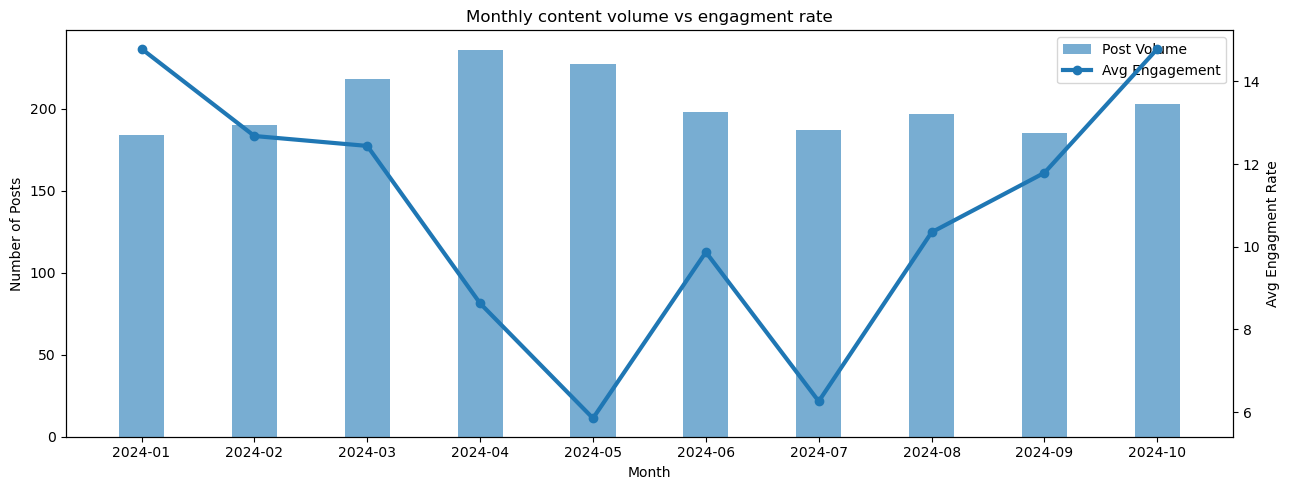

<Figure size 640x480 with 0 Axes>

In [10]:
# Q5 - Visualize monthly trend
if len(q5) > 0:
    fig,ax1 = plt.subplots(figsize = (13,5))
    ax2 = ax1.twinx()

    ax1.bar(q5["month"], q5["total_posts"], width =0.4, alpha = 0.6, label = "Post Volume")
    ax2.plot(q5["month"], q5["avg_engagement"],linewidth = 3, marker = "o", label = "Avg Engagement")
    
    ax1.set_title("Monthly content volume vs engagment rate")
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Number of Posts")
    ax2.set_ylabel("Avg Engagment Rate")
    plt.xticks(rotation=45, ha = "right")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc = "upper right")
    
    plt.tight_layout()
    plt.show()
    plt.savefig("monthly_trend.png")
    

In [11]:
# Q7 - Sentiment impact 
q7 = run_query(f"""
    SELECT 
        sentiment,
        COUNT(*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        ROUND(AVG(likes),0) AS avg_likes,
        ROUND(AVG(shares),0) AS avg_shares,
        ROUND(AVG(comments),0) AS avg_comments
    FROM {table_name}
    WHERE sentiment IS NOT NULL
    GROUP BY sentiment
    ORDER BY avg_engagement DESC
""", "Q7 - Sentiment Impact on Engagement")


 Q7 - Sentiment Impact on Engagement
--------------------------------------------------


,sentiment,total_posts,avg_engagement,avg_likes,avg_shares,avg_comments
0,Positive,2503,12.41,7804.0,829.0,347.0
1,Negative,750,11.39,7162.0,818.0,332.0
2,Neutral,1747,10.17,7315.0,852.0,333.0


### Step 4 - Platfor & Franchise performance  
This queries track **how each franchise perform across platforms**


In [12]:
# Q8 - Franchise group performance
q8 = run_query(f"""
    SELECT 
        franchise_group,
        COUNT(*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        SUM(likes) AS total_likes,
        SUM(shares) AS total_share,
        SUM(comments) AS total_comments,
        ROUND(AVG(followers),0) AS avg_follower
    FROM {table_name}
    WHERE franchise_group IS NOT NULL
    GROUP BY franchise_group
    ORDER BY avg_engagement DESC
""","Q8 - Franchise group performance")




 Q8 - Franchise group performance
--------------------------------------------------


,franchise_group,total_posts,avg_engagement,total_likes,total_share,total_comments,avg_follower
0,Lifestyle & Culture,1259,13.49,9263640,1033638,410559,247571.0
1,Tech & Business,816,12.54,5899917,640605,276980,245132.0
2,Education & Learning,413,11.40,3326562,366163,149610,248028.0
3,Health & Wellness,810,10.69,6392306,717350,287544,253119.0
4,Entertainment & Gaming,908,10.21,6972665,757189,312005,257078.0
5,Sports & Fitness,794,9.47,5829102,661222,262796,248346.0


In [13]:
# Q8 - Franchise x Platform cross analysis
q9 = run_query(f"""
    SELECT 
        franchise_group,
        platform,
        COUNT(*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement
    FROM {table_name}
    WHERE franchise_group IS NOT NULL
    GROUP BY franchise_group, platform
    ORDER BY franchise_group, avg_engagement DESC
""", "Q9 - Franchise and platform cross analysis")


 Q9 - Franchise and platform cross analysis
--------------------------------------------------


,franchise_group,platform,total_posts,avg_engagement
0,Education & Learning,TikTok,71,25.75
1,Education & Learning,Instagram,106,13.66
2,Education & Learning,YouTube,48,8.58
3,Education & Learning,Facebook,73,7.74
4,Education & Learning,LinkedIn,41,4.15
5,Education & Learning,Twitter,74,3.84
6,Entertainment & Gaming,TikTok,133,39.85
7,Entertainment & Gaming,YouTube,94,11.00
8,Entertainment & Gaming,Instagram,245,6.97
9,Entertainment & Gaming,Facebook,183,3.78


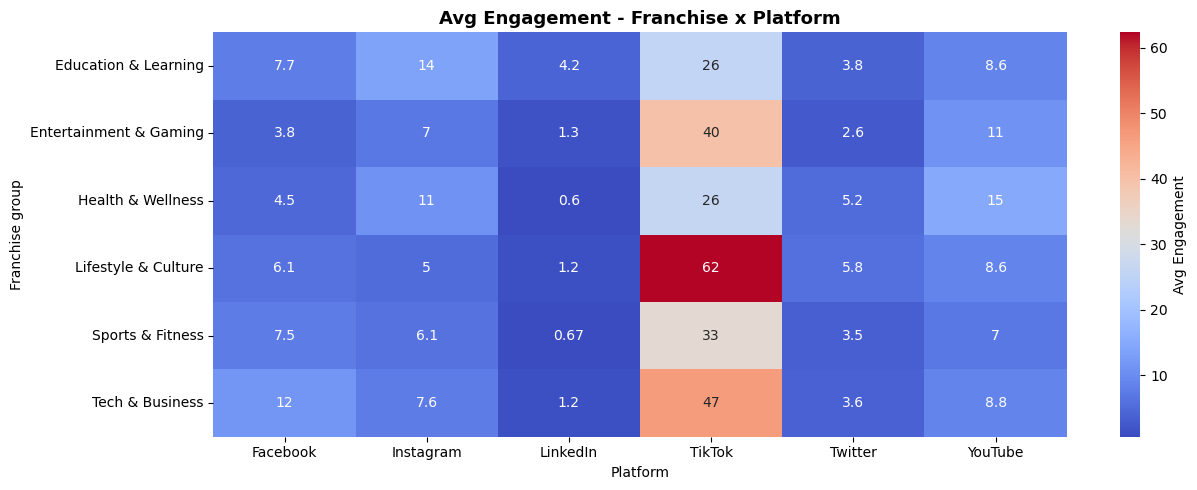

<Figure size 640x480 with 0 Axes>

In [14]:
# Franchise heatmap - engagement 
pivot_df = q9.pivot_table(
    index = "franchise_group",
    columns = "platform",
    values = "avg_engagement",
    fill_value = 0
)

fig, ax = plt.subplots(figsize = (13,5))
sns.heatmap(pivot_df, annot = True, cmap = 'coolwarm', ax = ax, 
            cbar_kws = {"label": "Avg Engagement"})
ax.set_title("Avg Engagement - Franchise x Platform", fontsize = 13, fontweight = "bold")
ax.set_xlabel("Platform")
ax.set_ylabel("Franchise group")
plt.tight_layout()
plt.show()
plt.savefig("franchise_platform_heatmap")

### Step 5 - Community Engagement Analysis  
Tracking **how audiences interact** with content over time across franchise groups.  

In [15]:
# Q10 - Engagement rate by follower tier 
q10 = run_query(f"""
    SELECT 
        CASE 
            WHEN followers <10000 THEN '1. Micro (<10K)'
            WHEN followers BETWEEN 10000 AND 99999 THEN '2. Mid (10K - 100K)'
            WHEN followers BETWEEN 100000 AND 999999 THEN '3. Macro (100K-1M)'
            ELSE  '4. Mega (1M+)'
        END AS follower_tier,
        COUNT(*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        ROUND(AVG(likes),0) AS avg_likes,
        ROUND(AVG(shares),0) AS avg_shares
    FROM {table_name}
    WHERE followers IS NOT NULL
    GROUP BY follower_tier
    ORDER BY follower_tier    
""","Q10 - Engagement by Follower tier (Influencer analysis)") 


 Q10 - Engagement by Follower tier (Influencer analysis)
--------------------------------------------------


,follower_tier,total_posts,avg_engagement,avg_likes,avg_shares
0,1. Micro (<10K),97,241.57,8311.0,796.0
1,2. Mid (10K - 100K),910,24.27,7659.0,813.0
2,3. Macro (100K-1M),3993,2.97,7490.0,841.0


In [16]:
# Q11 - Performance of different types of account: verified and non-verified
q11 = run_query(f"""
    SELECT 
        CASE WHEN is_verified = 1 THEN 'Verified '
             ELSE 'Not Verified' 
        END AS account_type,
        platform,
        COUNT(*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        ROUND(AVG(likes),0) AS avg_likes,
        ROUND(AVG(followers),0) AS avg_followers
    FROM {table_name}
    GROUP BY is_verified, platform
    ORDER BY is_verified, avg_engagement DESC        
""","Q11 - Verified vs Non-Verified Account Performance")


 Q11 - Verified vs Non-Verified Account Performance
--------------------------------------------------


,account_type,platform,total_posts,avg_engagement,avg_likes,avg_followers
0,Not Verified,TikTok,561,41.21,26217.0,256557.0
1,Not Verified,YouTube,339,10.93,10145.0,263482.0
2,Not Verified,Instagram,973,7.18,4961.0,245382.0
3,Not Verified,Facebook,719,6.15,4176.0,242963.0
4,Not Verified,Twitter,743,4.03,2386.0,254864.0
5,Not Verified,LinkedIn,358,1.26,1035.0,254500.0
6,Verified,TikTok,197,41.72,24612.0,250873.0
7,Verified,Instagram,310,9.08,4889.0,248591.0
8,Verified,Facebook,265,8.09,4073.0,244353.0
9,Verified,YouTube,140,7.57,9569.0,266111.0


In [17]:
# Q12 - Media vs no-media content performance
q12 = run_query(f"""
    SELECT 
        CASE WHEN has_media = TRUE THEN 'Has Media'
             ELSE 'Text Only'
        END AS media_type,
        platform,
        COUNT(*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        ROUND(AVG(likes),0) AS avg_likes,
        ROUND(AVG(shares),0) AS avg_shares,
        ROUND(AVG(comments),0) AS avg_comments
    FROM {table_name}
    GROUP BY media_type, platform
    ORDER BY media_type, avg_engagement DESC
""", "Q12- Media vs Text-Only Content Performance")



 Q12- Media vs Text-Only Content Performance
--------------------------------------------------


,media_type,platform,total_posts,avg_engagement,avg_likes,avg_shares,avg_comments
0,Has Media,TikTok,653,35.30,25721.0,2499.0,1031.0
1,Has Media,YouTube,398,9.44,9689.0,960.0,503.0
2,Has Media,Instagram,1092,7.73,4931.0,152.0,243.0
3,Has Media,Facebook,828,7.40,4126.0,501.0,196.0
4,Has Media,Twitter,839,4.40,2429.0,999.0,149.0
5,Has Media,LinkedIn,415,1.37,1010.0,252.0,76.0
6,Text Only,TikTok,105,78.92,26291.0,2505.0,956.0
7,Text Only,YouTube,81,12.47,11391.0,1089.0,460.0
8,Text Only,Instagram,191,7.13,5015.0,143.0,231.0
9,Text Only,Twitter,155,3.48,2370.0,1053.0,143.0


In [18]:
# Q13 - Hashtag count impact on engagement
q13 = run_query(f"""
    SELECT 
        platform,
        CASE 
            WHEN hashtag_count = 0 THEN '0 hashtags'
            WHEN hashtag_count BETWEEN 1 and 9 THEN '1-10 hashtags'
            WHEN hashtag_count BETWEEN 10 and 19 THEN '11-20 hashtags'
            ELSE '20+ hashtags'
        END AS hashtag_bucket,
        -- platform,
        COUNT(*) AS total_posts,
        ROUND(AVG(engagement_rate),2) AS avg_engagement,
        ROUND(AVG(likes),0) AS avg_likes
    FROM {table_name}
    GROUP BY platform , hashtag_bucket
    ORDER BY  avg_engagement DESC
""", "Q13 - Hastag Count for Engagement")


 Q13 - Hastag Count for Engagement
--------------------------------------------------


,platform,hashtag_bucket,total_posts,avg_engagement,avg_likes
0,TikTok,1-10 hashtags,238,51.68,24543.0
1,TikTok,20+ hashtags,260,38.72,26327.0
2,TikTok,11-20 hashtags,241,34.95,26561.0
3,TikTok,0 hashtags,19,28.79,24673.0
4,YouTube,20+ hashtags,179,10.66,9873.0
5,YouTube,0 hashtags,20,10.30,9281.0
6,YouTube,1-10 hashtags,123,10.08,10007.0
7,YouTube,11-20 hashtags,157,8.99,10160.0
8,Instagram,11-20 hashtags,427,8.28,5026.0
9,Facebook,20+ hashtags,337,7.58,4193.0


### Step 6  - Export KPI Summary for Power BI 

In [19]:
# create exports folder
os.makedirs("powerbi_exports", exist_ok = True)
# All KPI tables to export
exports = {
    "kpi_platform_engagement"  : q1,
    "kpi_content_type"         : q2,
    "kpi_best_hours"           : q3,
    "kpi_best_days"            : q4,
    "kpi_monthly_trend"        : q5,
    "kpi_top_posts"            : q6,
    "kpi_sentiment_impact"     : q7,
    "kpi_franchise_performance" : q8,
    "kpi_franchise_platform"   : q9,
    "kpi_follower_tiers"       : q10,
    "kpi_media_vs_text"        : q11,
    "kpi_hastag_impact"        : q12,
}

for name in ["q1", "q2", "q3", "q4", "q5", "q6"]:
    val = eval(name)
    print(name, type(eval))

print("Exporting KPI tables for Power BI ... \n")
for filename, df_export in exports.items():
    path = f"powerbi_exports/{filename}.csv"
    df_export.to_csv(path, index = False)
    print(f" {filename}.csv  ({len(df_export)} rows)")

print(f"\n All exports saved to: powerbi_exports/")





q1 <class 'builtin_function_or_method'>
q2 <class 'builtin_function_or_method'>
q3 <class 'builtin_function_or_method'>
q4 <class 'builtin_function_or_method'>
q5 <class 'builtin_function_or_method'>
q6 <class 'builtin_function_or_method'>
Exporting KPI tables for Power BI ... 

 kpi_platform_engagement.csv  (6 rows)
 kpi_content_type.csv  (17 rows)
 kpi_best_hours.csv  (10 rows)
 kpi_best_days.csv  (7 rows)
 kpi_monthly_trend.csv  (10 rows)
 kpi_top_posts.csv  (10 rows)
 kpi_sentiment_impact.csv  (3 rows)
 kpi_franchise_performance.csv  (6 rows)
 kpi_franchise_platform.csv  (36 rows)
 kpi_follower_tiers.csv  (3 rows)
 kpi_media_vs_text.csv  (12 rows)
 kpi_hastag_impact.csv  (12 rows)

 All exports saved to: powerbi_exports/


In [20]:
# Close database connection
connection.close()
print("Database connection closed ")

Database connection closed 


### Step 7 -  Boolean search filter library  
This is the **social listening layer** - simulating how Sprinklr tool use Boolean queries to filter and classify content by topic, brand, and sentiment.  

Boolean query syntax used in Sprinklr:  
- AND  
- OR  
- NOT  
- " " - exact phrase match
- ( ) - group conditions  



In [21]:
def apply_boolean_filter(df, query_str, text_col = "category"):
    query_str = query_str.strip()

    def term_match(df, term):
        term = term.strip().strip('"').lower()
        return df[text_col].str.lower().str.contains(term, na = False)

    def parse_boolean(df, expr):
        # handle NOT first
        if expr.upper().startswith("NOT "):
            return ~parse_boolean(df, expr[4:].strip())

        # split on OR (lowest precedence)
        or_parts = re.split(r'\bOR\b', expr, flags=re.IGNORECASE)
        if len(or_parts) > 1:
            result = parse_boolean(df, or_parts[0].strip())
            for part in or_parts[1:]:
                result = result | parse_boolean(df, part.strip())
            return result

        # split on AND
        and_parts = re.split(r'\bAND\b', expr, flags=re.IGNORECASE)
        if len(and_parts) > 1:
            result = parse_boolean(df, and_parts[0:].strip())
            for part in and_parts[1:]:
                result = result | parse_boolean(df, part.strip())
            return result

        # strip parentheses
        if expr.startswith("(") and expr.endswith(")"):
            return parse_boolean(df, expr[1:-1].strip())
        return term_match(df, expr)

    mask = parse_boolean(df, query_str)
    return df[mask].copy()

print("Boolean filter engine ready")
print(" Usage: apply_boolean_filter(df,'Entertainment OR gaming')")



    

Boolean filter engine ready
 Usage: apply_boolean_filter(df,'Entertainment OR gaming')


In [22]:
df_db = pd.read_sql(f"SELECT * FROM {table_name}", connection)

boolean_queries = {
    "Entertaiment content": "Entertainment OR Gaming",
    "Health & wellness content": "Health OR Food OR Fitness",
    "Lifestyle cluster": "(Lifestyle OR Fashion OR Travel) AND NOT Business",
    "High-value content (excl. education)": "(Entertainment OR Sports OR Gaming) AND NOT Education",
    "Professional content only": "Business OR Technology OR Education",
    "Engagement-focused: exclude low-value": "(Entertainment OR Gaming OR Sports) AND NOT (Business OR Education)",
}

print(" Boolean Query Results\n")
print(f"{'Query':<45} {'Matches':>8} {'% of total':>12} {'Avg Eng%':>10}")
print("-"*80)

query_results = {}
for label, query in boolean_queries.items():
    result = apply_boolean_filter(df_db, query, text_col = "category")
    pct = len(result)/len(df_db)*100
    avg_eng = result["engagement_rate"].mean() if len(result) else 0
    query_results[label] = result
    print(f"{label:<45} {len(result):>8,} {pct:>11.1f}% {avg_eng:>9.2f}%")


print(f"Load {len(df_db):,} rows into memory for Boolean filtering")
df_db.head(2)

ProgrammingError: Cannot operate on a closed database.